<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%202/Week_2_Lecture_5_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=0HbRnFTOOms) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%202/DL4CV_Week02_Part05.pdf)

In [ ]:
# Week 2, Lecture 5: Image Segmentation
from IPython.display import HTML, display

VIDEO_ID = "0HbRnFTOOms"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 2, Lecture 5: Image Segmentation <sup><mark style="background-color:gold">Code</mark></sup>

Companion notebook for **&sect;2.5 Image Segmentation**.

**Contents**
1. Segmentation and Gestalt grouping
2. Watershed segmentation
3. Superpixels and region merging
4. Graph-based segmentation
5. Probabilistic aggregation
6. Mean shift
7. Normalized cuts
8. Other methods and beyond images

## Review

The previous lectures built local features: detectors and descriptors that pick out and describe individual keypoints. Segmentation asks the complementary question: how do we group pixels into coherent regions?

**Image segmentation** partitions an image into regions whose pixels belong together, by color, texture, or spatial continuity. It is one of the oldest problems in vision, and the classical methods below (watershed, superpixels, graph cuts, mean shift, normalized cuts) still appear as building blocks and preprocessing steps inside modern deep pipelines. This lecture walks through the main families and shows each one running on a real image.

## Setup

Everything runs offline on images bundled with `scikit-image`, plus a few synthetic patterns. We use `scikit-image` for watershed, SLIC and Felzenszwalb segmentation, OpenCV for k-means and mean-shift filtering, and plain NumPy or SciPy for the from-scratch demos.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, util, color
import cv2

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def show(ax, im, title='', cmap=None):
    ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis('off')

def to_u8(im):                                  # float image in [0,1] to uint8 for OpenCV
    return (np.clip(im, 0, 1) * 255).astype(np.uint8)

## 1. Segmentation and Gestalt grouping

Long before algorithms, **Gestalt psychology** (early 20th century) described how human vision groups parts into wholes. Its slogan, *the whole is greater than the sum of its parts*, captures the idea that we perceive organized groups rather than isolated dots and edges.

Gestalt theory lists cues that make elements group together:

- **Proximity:** nearby elements are seen as one group.
- **Similarity:** elements that look alike group together.
- **Common region, closure, continuity, parallelism, symmetry, common fate:** enclosure, completion, smooth continuation, and shared motion all bind elements.

These rules are descriptive, not algorithmic: they explain *why* a grouping looks right, but they are too loose to directly produce a segmentation. The methods that follow turn these intuitions into computable criteria.

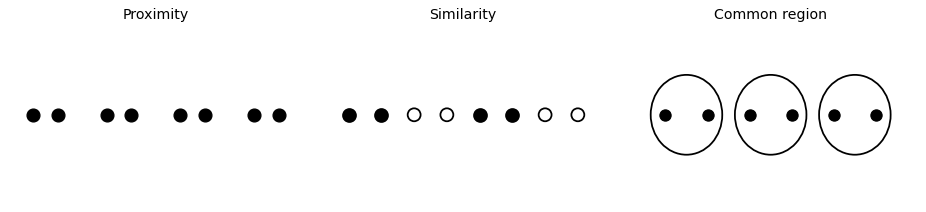

In [2]:
from matplotlib.patches import Ellipse

fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))

# Proximity: dots fall into perceptual pairs by spacing alone
ax = axes[0]
xs = np.array([0, 1, 3, 4, 6, 7, 9, 10], float)
ax.scatter(xs, np.zeros_like(xs), s=120, c='k')
ax.set_title('Proximity'); ax.set_xlim(-1, 11); ax.set_ylim(-1, 1); ax.axis('off')

# Similarity: filled vs open circles group by appearance
ax = axes[1]
fills = ['k', 'k', 'none', 'none', 'k', 'k', 'none', 'none']
for x, f in zip(range(8), fills):
    ax.scatter([x], [0], s=120, facecolors=f, edgecolors='k', linewidths=1.5)
ax.set_title('Similarity'); ax.set_xlim(-1, 8); ax.set_ylim(-1, 1); ax.axis('off')

# Common region: enclosure overrides equal spacing
ax = axes[2]
ax.scatter(range(6), np.zeros(6), s=90, c='k')
for cx in [0.5, 2.5, 4.5]:
    ax.add_patch(Ellipse((cx, 0), 1.7, 0.9, fill=False, lw=1.5))
ax.set_title('Common region'); ax.set_xlim(-1, 6); ax.set_ylim(-1, 1); ax.axis('off')

plt.tight_layout(); plt.show()

## 2. Watershed segmentation

The **watershed** method (Beucher and Lantuejoul, 1979) reads a grayscale image as a topographic surface: intensity is height, so bright pixels are peaks and dark pixels are valleys. If we flood the surface from local minima, water from different minima fills separate **catchment basins**, and the ridges where two floods meet become **watershed lines**, the region boundaries.

A few practical points:

- Watershed is usually run on the **gradient magnitude**, not the raw image, so that basins fall on smooth regions and ridges sit on strong edges.
- Flooding from every local minimum **over-segments**: noise creates many spurious minima, hence many tiny regions.
- The fix is **marker-controlled** watershed: place one marker inside each object (often from a distance transform) and flood only from those markers.

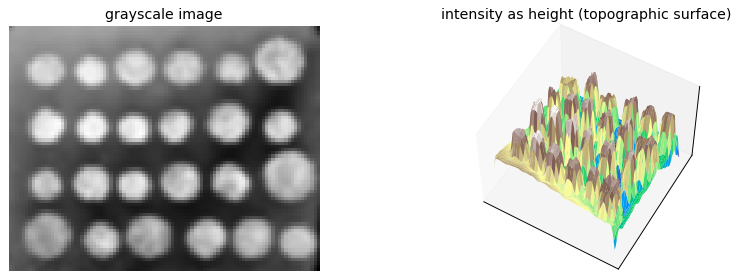

In [3]:
img = util.img_as_float(data.coins())
small = ndi.gaussian_filter(ndi.zoom(img, 0.25, order=1), 1.0)   # downsample for a readable surface
yy, xx = np.mgrid[0:small.shape[0], 0:small.shape[1]]

fig = plt.figure(figsize=(11, 3.4))
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(small, cmap='gray'); ax1.set_title('grayscale image'); ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(xx, yy, small, cmap='terrain', linewidth=0, antialiased=True)
ax2.set_title('intensity as height (topographic surface)')
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([]); ax2.view_init(elev=55, azim=-60)
plt.tight_layout(); plt.show()

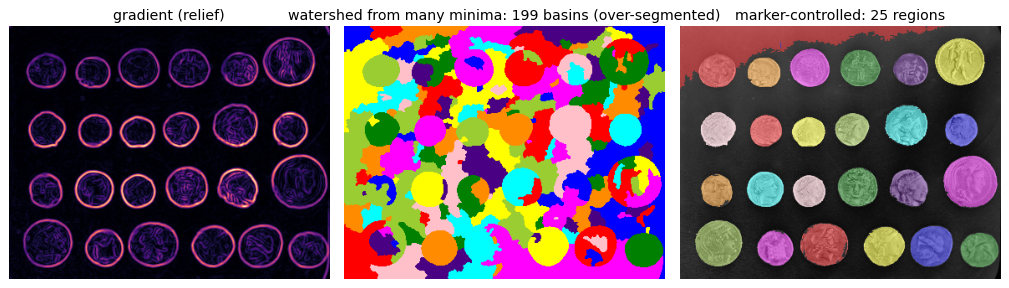

In [4]:
from skimage.filters import sobel, threshold_otsu
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

coins = util.img_as_float(data.coins())
grad  = sobel(ndi.gaussian_filter(coins, 1.0))

# Naive: seed a basin at every local minimum of the gradient -> far too many regions
seeds = peak_local_max(grad.max() - grad, min_distance=10)
m = np.zeros(grad.shape, bool); m[tuple(seeds.T)] = True
markers_over, _ = ndi.label(m)
ws_over = watershed(grad, markers_over)

# Marker-controlled: one marker per coin from the distance transform inside the foreground
bw   = ndi.binary_fill_holes(coins > threshold_otsu(coins))
dist = ndi.distance_transform_edt(bw)
peaks = peak_local_max(dist, min_distance=20, labels=bw)
mm = np.zeros(dist.shape, bool); mm[tuple(peaks.T)] = True
markers, _ = ndi.label(mm)
ws_marked = watershed(-dist, markers, mask=bw)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
show(ax[0], grad, 'gradient (relief)', cmap='magma')
show(ax[1], color.label2rgb(ws_over, bg_label=0),
     f'watershed from many minima: {ws_over.max()} basins (over-segmented)')
show(ax[2], color.label2rgb(ws_marked, image=coins, bg_label=0, alpha=0.4),
     f'marker-controlled: {ws_marked.max()} regions')
plt.tight_layout(); plt.show()

## 3. Superpixels and region merging

Two broad strategies build regions incrementally:

- **Region splitting** starts from the whole image and cuts it into finer pieces.
- **Region merging** starts from pixels and repeatedly merges similar neighbors.

A popular merging result is the **superpixel**: a small, compact group of pixels of near-uniform color. **SLIC** (Achanta et al., 2012) produces them by running a localized k-means in a combined color-and-position space. Superpixels are rarely the final answer; they are a compact preprocessing layer, replacing a million pixels with a few hundred regions that higher-level algorithms then group further.

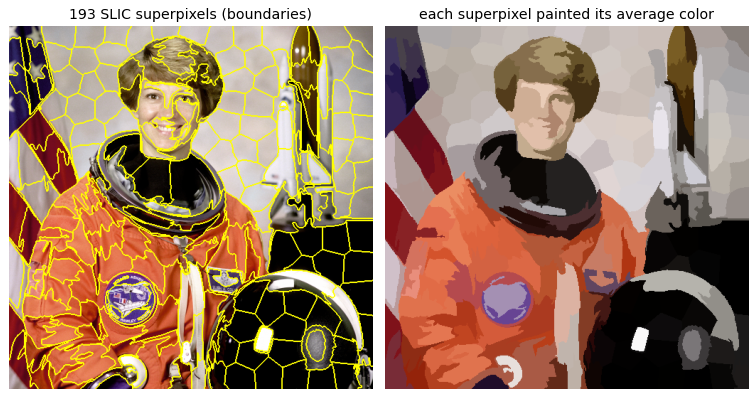

In [5]:
from skimage.segmentation import slic, mark_boundaries

img = util.img_as_float(data.astronaut())
seg = slic(img, n_segments=250, compactness=10, sigma=1, start_label=1)
avg = color.label2rgb(seg, img, kind='avg', bg_label=-1)     # paint each superpixel its mean color

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
show(ax[0], mark_boundaries(img, seg), f'{len(np.unique(seg))} SLIC superpixels (boundaries)')
show(ax[1], avg, 'each superpixel painted its average color')
plt.tight_layout(); plt.show()

## 4. Graph-based segmentation

Felzenszwalb and Huttenlocher (2004) treat the image as a graph $G=(V,E)$: pixels are vertices, edges join neighbors, and each edge weight $w(e)$ measures dissimilarity (for example the intensity difference between $N_8$ neighbors). Regions grow by merging, guided by a comparison of *within-region* and *between-region* differences.

For a region $C$, the **internal difference** is the largest edge in its minimum spanning tree:

$$\mathrm{Int}(C) = \max_{e \in \mathrm{MST}(C)} w(e)$$

The **difference between** two regions is the lightest edge connecting them:

$$\mathrm{Dif}(C_1, C_2) = \min_{\,e=(v_1,v_2),\; v_1 \in C_1,\; v_2 \in C_2} w(e)$$

The **minimum internal difference** adds a size-dependent penalty $\tau(C)=k/\lvert C\rvert$ that lets small regions merge more easily:

$$\mathrm{MInt}(C_1, C_2) = \min\big(\mathrm{Int}(C_1)+\tau(C_1),\; \mathrm{Int}(C_2)+\tau(C_2)\big)$$

The merge test compares the two:

$$D(C_1,C_2) = \begin{cases} \text{true}, & \text{if } \mathrm{Dif}(C_1,C_2) > \mathrm{MInt}(C_1,C_2) \\ \text{false}, & \text{otherwise} \end{cases}$$

Two regions are merged when $D$ is false, that is when the gap between them is no larger than the variation already inside them. The single parameter $k$ sets the preferred region scale.

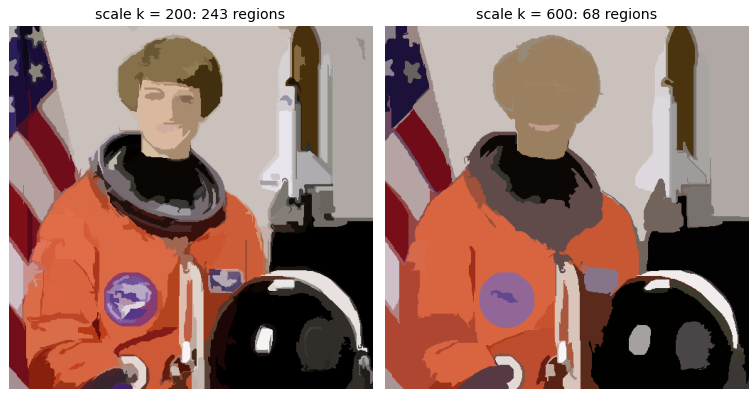

In [6]:
from skimage.segmentation import felzenszwalb

img = util.img_as_float(data.astronaut())
fine   = felzenszwalb(img, scale=200, sigma=0.8, min_size=100)
coarse = felzenszwalb(img, scale=600, sigma=0.8, min_size=200)   # larger k -> fewer, bigger regions

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
show(ax[0], color.label2rgb(fine,   img, kind='avg', bg_label=-1),
     f'scale k = 200: {len(np.unique(fine))} regions')
show(ax[1], color.label2rgb(coarse, img, kind='avg', bg_label=-1),
     f'scale k = 600: {len(np.unique(coarse))} regions')
plt.tight_layout(); plt.show()

## 5. Probabilistic aggregation

Alpert et al. (2007) merge regions with a **probabilistic, bottom-up** rule that combines two cues: gray-level similarity and texture similarity. Each pair of neighboring regions $i,j$ gets a merging likelihood $p_{ij}$. Starting from one region per pixel, a coarser graph is built by selecting a subset of seed regions $C$ and absorbing any region that is **strongly coupled** to them:

$$\frac{\sum_{j \in C} p_{ij}}{\sum_{j \in V} p_{ij}} > \text{threshold} \quad (\text{typically } 0.2)$$

The assignment found at a coarse level is propagated back to the finer regions, and the process repeats, giving a multiscale segmentation known as **segmentation by weighted aggregation (SWA)**. This section is concept-only: the merging and splitting mechanics are shown by the demos above and below.

## 6. Mean shift

**Mean shift** (Comaniciu and Meer, 2002) treats each pixel feature (color, or color plus position) as a sample from an unknown density, and segments by finding the **modes** (peaks) of that density: every pixel that climbs to the same peak forms one region.

The density is estimated by placing a kernel of bandwidth $h$ on each sample:

$$f(\mathbf{x}) = \sum_i k\!\left( \frac{\lVert \mathbf{x} - \mathbf{x}_i \rVert^2}{h^2} \right)$$

Its gradient points toward higher density and rearranges into a weighted-mean form:

$$\nabla f(\mathbf{x}) = \Big[\sum_i G(\mathbf{x}-\mathbf{x}_i)\Big]\, m(\mathbf{x}), \qquad m(\mathbf{x}) = \frac{\sum_i \mathbf{x}_i\, G(\mathbf{x}-\mathbf{x}_i)}{\sum_i G(\mathbf{x}-\mathbf{x}_i)} - \mathbf{x}$$

where $G = -k'$. The vector $m(\mathbf{x})$ is the **mean shift**: the offset from $\mathbf{x}$ to the local weighted mean of its neighbors. Following it repeatedly is a gradient ascent that lands on a mode:

$$\mathbf{y}_{k+1} = \frac{\sum_i \mathbf{x}_i\, G(\mathbf{y}_k - \mathbf{x}_i)}{\sum_i G(\mathbf{y}_k - \mathbf{x}_i)}$$

No density is ever computed explicitly; each point simply walks uphill to its peak.

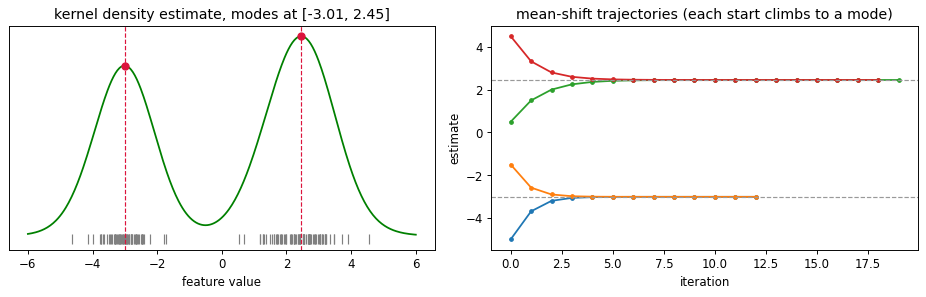

modes reached: [-3.01, 2.45]


In [7]:
rng = np.random.default_rng(1)
pts = np.concatenate([rng.normal(-3, 0.6, 60), rng.normal(2.5, 0.8, 80)])
h   = 0.8
grid = np.linspace(-6, 6, 400)

def kde(x, pts, h):
    u = (np.atleast_1d(x)[:, None] - pts[None, :]) / h
    return np.exp(-0.5 * u**2).sum(1) / (len(pts) * h * np.sqrt(2 * np.pi))

def mean_shift_1d(y, pts, h, iters=100, tol=1e-6):
    traj = [y]
    for _ in range(iters):
        w = np.exp(-0.5 * ((y - pts) / h)**2)
        y_new = (w * pts).sum() / w.sum()
        traj.append(y_new)
        if abs(y_new - y) < tol: break
        y = y_new
    return np.array(traj)

dens   = kde(grid, pts, h)
starts = [-5.0, -1.5, 0.5, 4.5]
trajs  = [mean_shift_1d(s, pts, h) for s in starts]
modes  = sorted(set(round(float(t[-1]), 2) for t in trajs))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(grid, dens, color='green')
ax[0].plot(pts, np.full_like(pts, -0.004), '|', color='0.5', markersize=8)   # data rug
for m in modes:
    ax[0].axvline(m, ls='--', color='crimson', lw=1)
    ax[0].plot(m, kde(m, pts, h)[0], 'o', color='crimson')
ax[0].set_title(f'kernel density estimate, modes at {modes}')
ax[0].set_xlabel('feature value'); ax[0].set_yticks([])

for s, t in zip(starts, trajs):
    ax[1].plot(range(len(t)), t, marker='o', ms=3)
for m in modes:
    ax[1].axhline(m, ls='--', color='0.6', lw=1)
ax[1].set_title('mean-shift trajectories (each start climbs to a mode)')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel('estimate')
plt.tight_layout(); plt.show()
print('modes reached:', modes)

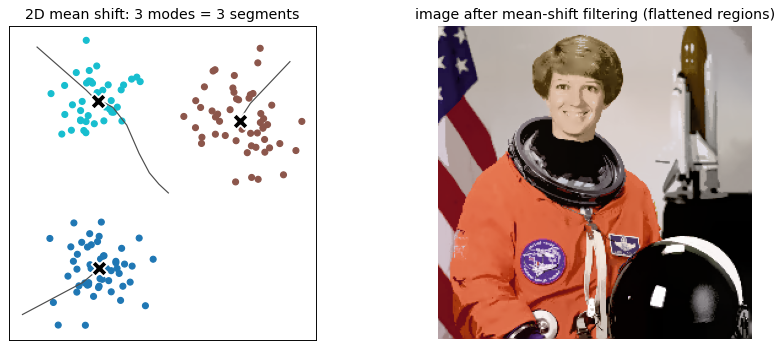

unique colors 38111 -> 9184 after mean shift


In [8]:
rng = np.random.default_rng(2)
clouds = [rng.normal([0, 0], 0.5, (50, 2)),
          rng.normal([3, 3], 0.6, (50, 2)),
          rng.normal([0, 3.5], 0.4, (40, 2))]
P = np.vstack(clouds)
h = 0.9

def mean_shift_point(y, pts, h, iters=200, tol=1e-5):
    for _ in range(iters):
        w = np.exp(-0.5 * ((pts - y)**2).sum(1) / h**2)
        y_new = (w[:, None] * pts).sum(0) / w.sum()
        if np.linalg.norm(y_new - y) < tol: break
        y = y_new
    return y

peaks = np.array([mean_shift_point(p.copy(), P, h) for p in P])

# group points whose peaks coincide -> one label (segment) per mode
labels = -np.ones(len(P), int); centers = []
for i, pk in enumerate(peaks):
    for cid, c in enumerate(centers):
        if np.linalg.norm(pk - c) < 0.5:
            labels[i] = cid; break
    else:
        labels[i] = len(centers); centers.append(pk)
centers = np.array(centers)

# left: 2D clustering by mode, with a few full ascent paths overlaid
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(P[:, 0], P[:, 1], c=labels, cmap='tab10', s=25)
for s in np.array([[-1.5, -1.0], [4.0, 4.2], [-1.2, 4.5], [1.5, 1.5]]):
    path = [s.copy()]; y = s.copy()
    for _ in range(60):
        w = np.exp(-0.5 * ((P - y)**2).sum(1) / h**2)
        y = (w[:, None] * P).sum(0) / w.sum(); path.append(y.copy())
    path = np.array(path)
    ax[0].plot(path[:, 0], path[:, 1], '-', color='0.3', lw=1)
ax[0].scatter(centers[:, 0], centers[:, 1], marker='X', s=180,
              c='k', edgecolors='w', linewidths=1.5, zorder=5)
ax[0].set_title(f'2D mean shift: {len(centers)} modes = {len(centers)} segments')
ax[0].set_aspect('equal'); ax[0].set_xticks([]); ax[0].set_yticks([])

# right: the same idea on real pixels, via OpenCV mean-shift filtering
img = util.img_as_float(data.astronaut())[::2, ::2]
bgr = cv2.cvtColor(to_u8(img), cv2.COLOR_RGB2BGR)
flat = cv2.cvtColor(cv2.pyrMeanShiftFiltering(bgr, sp=20, sr=35), cv2.COLOR_BGR2RGB)
show(ax[1], flat, 'image after mean-shift filtering (flattened regions)')
plt.tight_layout(); plt.show()

n0 = len(np.unique(to_u8(img).reshape(-1, 3), axis=0))
n1 = len(np.unique(flat.reshape(-1, 3), axis=0))
print(f'unique colors {n0} -> {n1} after mean shift')

## 7. Normalized cuts

Segmentation can also be posed as **graph splitting**. Build a graph where edge weights $w_{ij}$ encode pixel similarity, and cut it into two parts $A$ and $B$. The weight removed is the **cut**:

$$\mathrm{cut}(A,B) = \sum_{i \in A,\; j \in B} w_{ij}$$

Minimizing the cut directly has a well-known failure: the cheapest cut often just peels off a single isolated pixel. Shi and Malik (2000) fix this by **normalizing** the cut by how strongly each side connects to the whole graph. With

$$\mathrm{assoc}(A,V) = \sum_{i \in A,\; j \in V} w_{ij},$$

the **normalized cut** is

$$\mathrm{Ncut}(A,B) = \frac{\mathrm{cut}(A,B)}{\mathrm{assoc}(A,V)} + \frac{\mathrm{cut}(A,B)}{\mathrm{assoc}(B,V)}$$

Dividing by the association penalizes tiny fragments, so the split is balanced. The exact optimum is NP-complete, but a good approximation comes from a **spectral relaxation**: solve the generalized eigenproblem $(D-W)\,\mathbf{y} = \lambda\, D\,\mathbf{y}$ and threshold the eigenvector of the second-smallest eigenvalue (the Fiedler vector), where $W$ is the affinity matrix and $D$ its diagonal degree matrix.

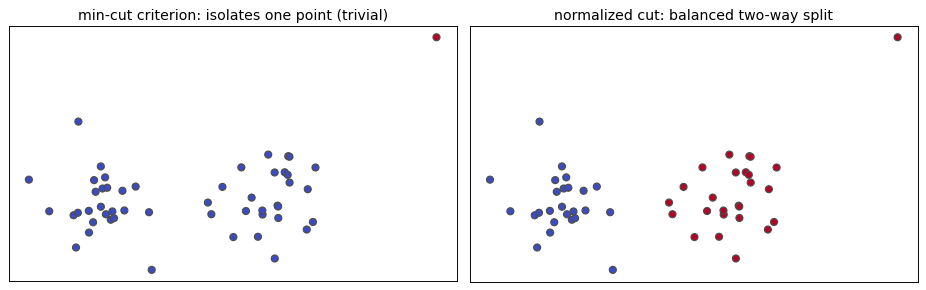

Ncut split sizes: [25 26]


In [9]:
from scipy.linalg import eigh

rng = np.random.default_rng(3)
A = rng.normal([0, 0], 0.45, (25, 2))
B = rng.normal([3, 0.3], 0.5, (25, 2))
outlier = np.array([[6.0, 3.0]])                       # one far, weakly connected point
pts = np.vstack([A, B, outlier])

d2 = ((pts[:, None, :] - pts[None, :, :])**2).sum(-1)
W  = np.exp(-d2 / (2 * 1.0**2)); np.fill_diagonal(W, 0)
D  = np.diag(W.sum(1))

# spectral Ncut: Fiedler vector of the generalized eigenproblem, then threshold at 0
_, vecs = eigh(D - W, D)
ncut_label = (vecs[:, 1] > 0).astype(int)

# raw min-cut proxy: the cheapest single-node cut removes the least-connected point
mincut_label = np.zeros(len(pts), int)
mincut_label[np.argmin(W.sum(1))] = 1                  # that node is the outlier

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(pts[:, 0], pts[:, 1], c=mincut_label, cmap='coolwarm', s=35, edgecolors='0.3')
ax[0].set_title('min-cut criterion: isolates one point (trivial)')
ax[1].scatter(pts[:, 0], pts[:, 1], c=ncut_label, cmap='coolwarm', s=35, edgecolors='0.3')
ax[1].set_title('normalized cut: balanced two-way split')
for a in ax: a.set_aspect('equal'); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print('Ncut split sizes:', np.bincount(ncut_label))

## 8. Other methods and beyond images

Many more segmentation methods exist, including **k-means** clustering in color space and **Markov / Conditional Random Fields** that add spatial smoothness priors. k-means is the simplest: pick $K$, cluster the pixel colors, and recolor each pixel by its cluster center.

**Do we still need these with deep learning?** To an extent, yes. Classical segmentation shaped early deep pipelines: the first R-CNN used a min-cut variant, Constrained Parametric Min-Cuts, to propose regions. These ideas also extend **beyond single images**: *shot boundary detection* splits a video into shots by finding frames where appearance changes abruptly, and *motion segmentation* isolates moving objects.

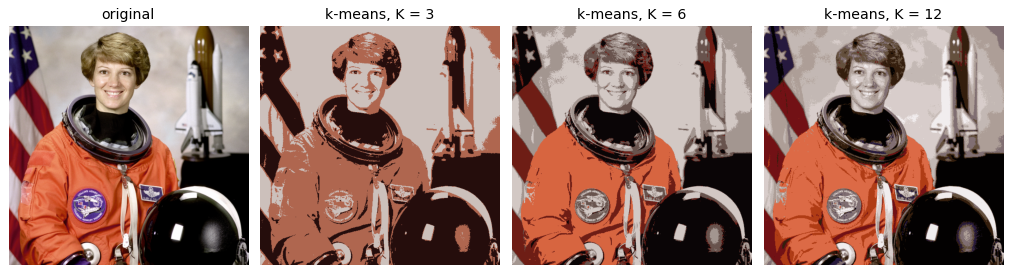

In [10]:
img = util.img_as_float(data.astronaut())
Z = img.reshape(-1, 3).astype(np.float32)
crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)

fig, ax = plt.subplots(1, 4, figsize=(12, 3.2))
show(ax[0], img, 'original')
for a, K in zip(ax[1:], [3, 6, 12]):
    _, lab, ctr = cv2.kmeans(Z, K, None, crit, 5, cv2.KMEANS_PP_CENTERS)
    quant = np.clip(ctr[lab.flatten()].reshape(img.shape), 0, 1)
    show(a, quant, f'k-means, K = {K}')
plt.tight_layout(); plt.show()

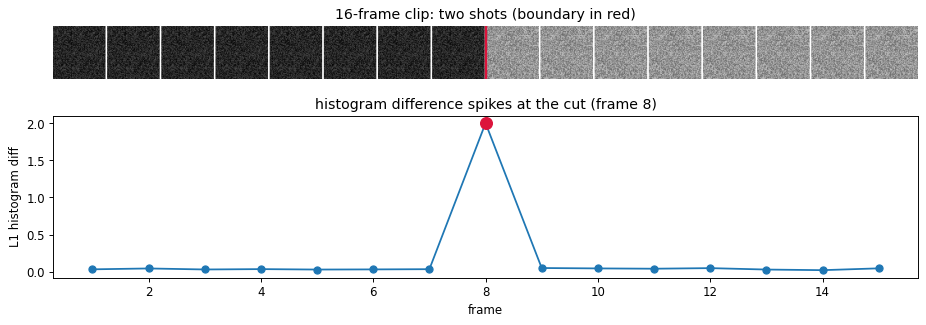

detected shot boundary before frame 8


In [11]:
rng = np.random.default_rng(4)
def jitter(base, amp=6):
    return np.clip(base + rng.integers(-amp, amp, base.shape), 0, 255).astype(np.uint8)

scene_a = rng.integers(30, 90,  (64, 64)).astype(np.uint8)
scene_b = rng.integers(120, 200, (64, 64)).astype(np.uint8)
frames  = [jitter(scene_a) for _ in range(8)] + [jitter(scene_b) for _ in range(8)]

def hist(f):
    h, _ = np.histogram(f, bins=32, range=(0, 255)); return h / h.sum()

diffs = np.array([np.abs(hist(frames[i]) - hist(frames[i - 1])).sum()
                  for i in range(1, len(frames))])
boundary = int(np.argmax(diffs)) + 1                 # frame index where the shot changes

sep = np.full((64, 2), 255, np.uint8)
strip = frames[0]
for f in frames[1:]:
    strip = np.hstack([strip, sep, f])

fig, ax = plt.subplots(2, 1, figsize=(11, 4.2), gridspec_kw={'height_ratios': [1, 1.2]})
ax[0].imshow(strip, cmap='gray'); ax[0].axis('off')
ax[0].axvline(boundary * 66 - 1, color='crimson', lw=2)
ax[0].set_title('16-frame clip: two shots (boundary in red)')
ax[1].plot(range(1, len(frames)), diffs, marker='o')
ax[1].plot(boundary, diffs[boundary - 1], 'o', color='crimson', ms=10)
ax[1].set_title(f'histogram difference spikes at the cut (frame {boundary})')
ax[1].set_xlabel('frame'); ax[1].set_ylabel('L1 histogram diff')
plt.tight_layout(); plt.show()
print('detected shot boundary before frame', boundary)

---

## Summary

| Method | Core idea |
|---|---|
| Gestalt grouping | Perceptual cues (proximity, similarity, closure, and more) that motivate grouping; descriptive, not algorithmic |
| Watershed | Flood the intensity or gradient surface from minima; basins are regions, ridges are boundaries; markers avoid over-segmentation |
| Superpixels (SLIC) | Localized k-means in color-plus-position space; compact regions used as preprocessing |
| Graph-based (Felzenszwalb) | Merge two regions when the between-region gap is no larger than the within-region variation ($\mathrm{Dif} \le \mathrm{MInt}$) |
| Probabilistic aggregation | Bottom-up SWA merging using gray and texture coupling above a threshold |
| Mean shift | Climb the feature-density gradient to a mode; pixels sharing a mode share a region |
| Normalized cuts | Balanced graph split minimizing $\mathrm{Ncut}$; spectral relaxation via the Fiedler vector |
| k-means, MRF and CRF | Color clustering; random-field models add spatial smoothness |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Chapter 5. Forsyth and Ponce, *Computer Vision: A Modern Approach*, Chapters 15 and 17. Shi and Malik, *Normalized Cuts and Image Segmentation*, IEEE TPAMI 2000. Comaniciu and Meer, *Mean Shift*, IEEE TPAMI 2002.

**To think about:** Why does the raw min-cut criterion favor tiny isolated regions, and how does normalization repair it? How does the mean-shift bandwidth $h$ trade the number of regions against detail? Derive the mean-shift update from the gradient of the kernel density (lecture homework). Which of these classical ideas can you still spot inside a modern segmentation network?